<a href="https://colab.research.google.com/github/FaraahJ/Data-Science-Internship-Assignments/blob/main/Week_3_One_Hot_Encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
df = pd.read_csv('/Diabetes-Classification.csv')
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,Male,25.0,Normal,100,5.7,No,No,Healthy,Regular,No
1,55,Female,30.0,High,120,6.4,Yes,Yes,Poor,No,Yes
2,65,Male,35.0,High,140,7.1,Yes,Yes,Poor,No,Yes
3,75,Female,40.0,High,160,7.8,Yes,Yes,Poor,No,Yes
4,40,Male,20.0,Normal,80,5.0,No,No,Healthy,NaN,No


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         128 non-null    int64  
 1   Gender                      128 non-null    object 
 2   BMI                         125 non-null    float64
 3   Blood Pressure              128 non-null    object 
 4   FBS                         128 non-null    int64  
 5   HbA1c                       128 non-null    float64
 6   Family History of Diabetes  126 non-null    object 
 7   Smoking                     126 non-null    object 
 8   Diet                        126 non-null    object 
 9   Exercise                    127 non-null    object 
 10  Diagnosis                   128 non-null    object 
dtypes: float64(2), int64(2), object(7)
memory usage: 11.1+ KB


In [63]:
df.isnull().sum()

,0
Age,0
Gender,0
BMI,3
Blood Pressure,0
FBS,0
HbA1c,0
Family History of Diabetes,2
Smoking,2
Diet,2
Exercise,1


In [64]:
df = df.dropna()
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,Male,25.0,Normal,100,5.7,No,No,Healthy,Regular,No
1,55,Female,30.0,High,120,6.4,Yes,Yes,Poor,No,Yes
2,65,Male,35.0,High,140,7.1,Yes,Yes,Poor,No,Yes
3,75,Female,40.0,High,160,7.8,Yes,Yes,Poor,No,Yes
5,50,Female,25.0,Normal,100,5.7,No,No,Healthy,Regular,No


In [65]:
from sklearn.preprocessing import LabelEncoder
cat_col=['Diagnosis']

le=LabelEncoder()

for col in cat_col:
  df[col]=le.fit_transform(df[col])

df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,Male,25.0,Normal,100,5.7,No,No,Healthy,Regular,0
1,55,Female,30.0,High,120,6.4,Yes,Yes,Poor,No,1
2,65,Male,35.0,High,140,7.1,Yes,Yes,Poor,No,1
3,75,Female,40.0,High,160,7.8,Yes,Yes,Poor,No,1
5,50,Female,25.0,Normal,100,5.7,No,No,Healthy,Regular,0


In [66]:
one_encoded=pd.get_dummies(df,columns=['Gender'])
one_encoded.head()

,Age,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis,Gender_Female,Gender_Male
0,45,25.0,Normal,100,5.7,No,No,Healthy,Regular,0,False,True
1,55,30.0,High,120,6.4,Yes,Yes,Poor,No,1,True,False
2,65,35.0,High,140,7.1,Yes,Yes,Poor,No,1,False,True
3,75,40.0,High,160,7.8,Yes,Yes,Poor,No,1,True,False
5,50,25.0,Normal,100,5.7,No,No,Healthy,Regular,0,True,False


In [67]:
cat_col=['Gender', 'Exercise', 'Blood Pressure', 'Family History of Diabetes', 'Smoking', 'Diet']
one_encoded= pd.get_dummies(df, columns=cat_col)

one_encoded.head()

,Age,BMI,FBS,HbA1c,Diagnosis,Gender_Female,Gender_Male,Exercise_No,Exercise_Regular,Blood Pressure_High,Blood Pressure_Low,Blood Pressure_Normal,Family History of Diabetes_No,Family History of Diabetes_Yes,Smoking_No,Smoking_Yes,Diet_Healthy,Diet_Poor
0,45,25.0,100,5.7,0,False,True,False,True,False,False,True,True,False,True,False,True,False
1,55,30.0,120,6.4,1,True,False,True,False,True,False,False,False,True,False,True,False,True
2,65,35.0,140,7.1,1,False,True,True,False,True,False,False,False,True,False,True,False,True
3,75,40.0,160,7.8,1,True,False,True,False,True,False,False,False,True,False,True,False,True
5,50,25.0,100,5.7,0,True,False,False,True,False,False,True,True,False,True,False,True,False


In [68]:
cat_col=[ 'Gender_Female',
       'Gender_Male', 'Exercise_No', 'Exercise_Regular', 'Blood Pressure_High',
       'Blood Pressure_Low', 'Blood Pressure_Normal',
       'Family History of Diabetes_No', 'Family History of Diabetes_Yes',
       'Smoking_No', 'Smoking_Yes', 'Diet_Healthy', 'Diet_Poor']
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in cat_col:
  one_encoded[col]=le.fit_transform(one_encoded[col])

one_encoded.head()

,Age,BMI,FBS,HbA1c,Diagnosis,Gender_Female,Gender_Male,Exercise_No,Exercise_Regular,Blood Pressure_High,Blood Pressure_Low,Blood Pressure_Normal,Family History of Diabetes_No,Family History of Diabetes_Yes,Smoking_No,Smoking_Yes,Diet_Healthy,Diet_Poor
0,45,25.0,100,5.7,0,0,1,0,1,0,0,1,1,0,1,0,1,0
1,55,30.0,120,6.4,1,1,0,1,0,1,0,0,0,1,0,1,0,1
2,65,35.0,140,7.1,1,0,1,1,0,1,0,0,0,1,0,1,0,1
3,75,40.0,160,7.8,1,1,0,1,0,1,0,0,0,1,0,1,0,1
5,50,25.0,100,5.7,0,1,0,0,1,0,0,1,1,0,1,0,1,0


In [69]:
#descriptive analysis of data

df.describe()


,Age,BMI,FBS,HbA1c,Diagnosis
count,118.00000,118.000000,118.000000,118.000000,118.000000
mean,43.09322,36.220339,163.559322,7.924576,0.254237
std,21.46792,16.542685,62.244698,2.178564,0.437288
min,12.00000,10.000000,80.000000,5.000000,0.000000
25%,28.00000,24.000000,120.000000,6.400000,0.000000
50%,40.00000,34.000000,160.000000,7.800000,0.000000
75%,56.50000,48.500000,220.000000,9.900000,0.750000
max,185.00000,105.000000,280.000000,12.000000,1.000000


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118 entries, 0 to 127
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         118 non-null    int64  
 1   Gender                      118 non-null    object 
 2   BMI                         118 non-null    float64
 3   Blood Pressure              118 non-null    object 
 4   FBS                         118 non-null    int64  
 5   HbA1c                       118 non-null    float64
 6   Family History of Diabetes  118 non-null    object 
 7   Smoking                     118 non-null    object 
 8   Diet                        118 non-null    object 
 9   Exercise                    118 non-null    object 
 10  Diagnosis                   118 non-null    int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 11.1+ KB


In [71]:
#exploratory data analysis - correlation heatmap
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,Male,25.0,Normal,100,5.7,No,No,Healthy,Regular,0
1,55,Female,30.0,High,120,6.4,Yes,Yes,Poor,No,1
2,65,Male,35.0,High,140,7.1,Yes,Yes,Poor,No,1
3,75,Female,40.0,High,160,7.8,Yes,Yes,Poor,No,1
5,50,Female,25.0,Normal,100,5.7,No,No,Healthy,Regular,0


In [72]:
df['Gender_index'] = df['Gender'].astype('category').cat.codes
df['Blood Pressure_index'] = df['Blood Pressure'].astype('category').cat.codes
df['Family History of Diabetes_index'] = df['Family History of Diabetes'].astype('category').cat.codes
df['Smoking_index'] = df['Smoking'].astype('category').cat.codes
df['Diet_index'] = df['Diet'].astype('category').cat.codes
df['Exercise_index'] = df['Exercise'].astype('category').cat.codes

df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis,Gender_index,Blood Pressure_index,Family History of Diabetes_index,Smoking_index,Diet_index,Exercise_index
0,45,Male,25.0,Normal,100,5.7,No,No,Healthy,Regular,0,1,2,0,0,0,1
1,55,Female,30.0,High,120,6.4,Yes,Yes,Poor,No,1,0,0,1,1,1,0
2,65,Male,35.0,High,140,7.1,Yes,Yes,Poor,No,1,1,0,1,1,1,0
3,75,Female,40.0,High,160,7.8,Yes,Yes,Poor,No,1,0,0,1,1,1,0
5,50,Female,25.0,Normal,100,5.7,No,No,Healthy,Regular,0,0,2,0,0,0,1


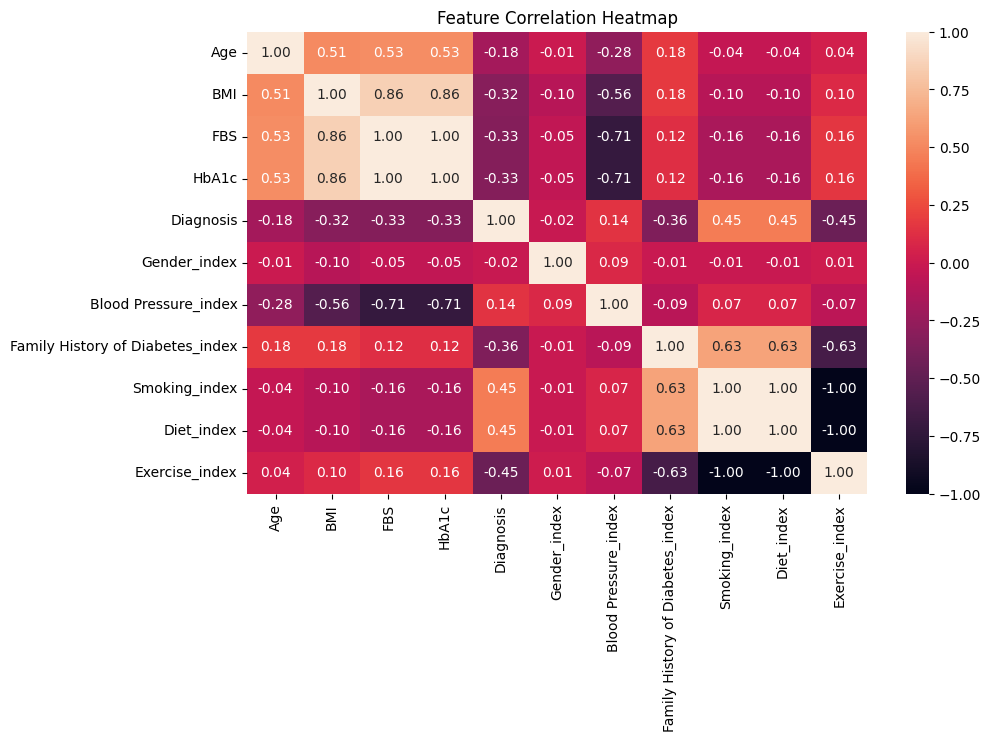

In [73]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [74]:
#boxplot

df['Gender_index'] = df['Gender'].astype('category').cat.codes
df['Blood Pressure_index'] = df['Blood Pressure'].astype('category').cat.codes
df['Family History of Diabetes_index'] = df['Family History of Diabetes'].astype('category').cat.codes
df['Smoking_index'] = df['Smoking'].astype('category').cat.codes
df['Diet_index'] = df['Diet'].astype('category').cat.codes
df['Exercise_index'] = df['Exercise'].astype('category').cat.codes

df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis,Gender_index,Blood Pressure_index,Family History of Diabetes_index,Smoking_index,Diet_index,Exercise_index
0,45,Male,25.0,Normal,100,5.7,No,No,Healthy,Regular,0,1,2,0,0,0,1
1,55,Female,30.0,High,120,6.4,Yes,Yes,Poor,No,1,0,0,1,1,1,0
2,65,Male,35.0,High,140,7.1,Yes,Yes,Poor,No,1,1,0,1,1,1,0
3,75,Female,40.0,High,160,7.8,Yes,Yes,Poor,No,1,0,0,1,1,1,0
5,50,Female,25.0,Normal,100,5.7,No,No,Healthy,Regular,0,0,2,0,0,0,1


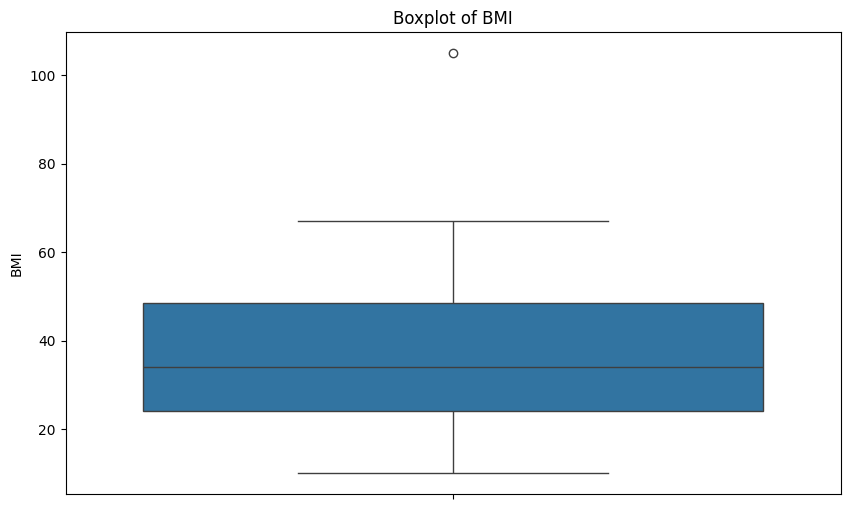

In [75]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df['BMI'])
plt.title('Boxplot of BMI')
plt.show()

In [76]:
#single outlier for BMI

In [77]:
#feature selection

from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func= f_classif, k=5)

In [78]:
x=one_encoded.drop('Diagnosis', axis=1)
y=one_encoded['Diagnosis']

In [79]:
x_selected=selector.fit_transform(x,y)
selected_features=x.columns[selector.get_support()]
print(selected_features)

Index(['Exercise_Regular', 'Smoking_No', 'Smoking_Yes', 'Diet_Healthy',
       'Diet_Poor'],
      dtype='object')


In [80]:
x1=one_encoded[selected_features]
x1

,Exercise_Regular,Smoking_No,Smoking_Yes,Diet_Healthy,Diet_Poor
0,1,1,0,1,0
1,0,0,1,0,1
2,0,0,1,0,1
3,0,0,1,0,1
5,1,1,0,1,0
...,...,...,...,...,...
123,0,0,1,0,1
124,0,0,1,0,1
125,0,0,1,0,1
126,0,0,1,0,1


In [81]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.3, random_state=10)
x1_train, x1_test, y_train, y_test=train_test_split(x,y,test_size=0.3, random_state=10)

In [82]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=5)
knn_selected=KNeighborsClassifier(n_neighbors=5)

In [83]:
knn.fit(x_train, y_train)
y_pred_knn=knn.predict(x_test)

knn_selected.fit(x1_train, y_train)
y_pred_knn1=knn_selected.predict(x1_test)

In [84]:
from sklearn.metrics import classification_report

print("nKNN Performance:")
print(classification_report(y_test, y_pred_knn))

print("nKNN_Selected Performance:")
print(classification_report(y_test, y_pred_knn1))

nKNN Performance:
              precision    recall  f1-score   support

           0       0.83      0.67      0.74        30
           1       0.17      0.33      0.22         6

    accuracy                           0.61        36
   macro avg       0.50      0.50      0.48        36
weighted avg       0.72      0.61      0.65        36

nKNN_Selected Performance:
              precision    recall  f1-score   support

           0       0.83      0.67      0.74        30
           1       0.17      0.33      0.22         6

    accuracy                           0.61        36
   macro avg       0.50      0.50      0.48        36
weighted avg       0.72      0.61      0.65        36



In [85]:
from sklearn import svm
from sklearn.svm import SVC

svm=SVC(kernel='rbf', probability=True, random_state=10 )
svm_selected=SVC(kernel='rbf', probability=True, random_state=10)

In [86]:
svm.fit(x_train, y_train)
y_pred_svm=svm.predict(x_test)

svm_selected.fit(x1_train, y_train)
y_pred_svm1=svm_selected.predict(x1_test)

In [87]:
from sklearn.metrics import classification_report

print("SVM Performance:")
print(classification_report(y_test, y_pred_svm))

print("SVM_Selected Performance:")
print(classification_report(y_test, y_pred_svm1))

SVM Performance:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        30
           1       0.00      0.00      0.00         6

    accuracy                           0.83        36
   macro avg       0.42      0.50      0.45        36
weighted avg       0.69      0.83      0.76        36

SVM_Selected Performance:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        30
           1       0.00      0.00      0.00         6

    accuracy                           0.83        36
   macro avg       0.42      0.50      0.45        36
weighted avg       0.69      0.83      0.76        36



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [88]:
#precision is ratio of all predicted positive cases with actual positive cases
#recall is ratio of all actual positive cases with predicted positive cases
#f1 score is mean of precision and recall

<Axes: >

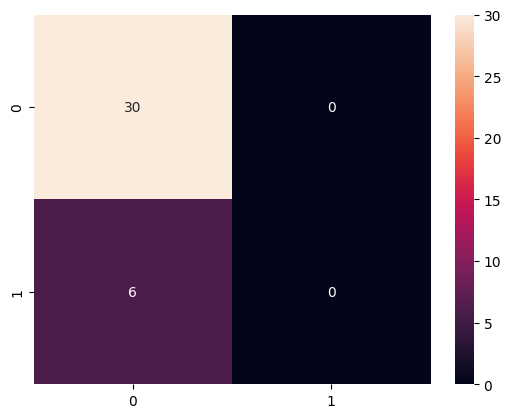

In [89]:
#confusion metrics show labelwise performance of model
#confusion plot and ROC curve for 'all features' model

from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred_svm)
sns.heatmap(cm,annot=True)

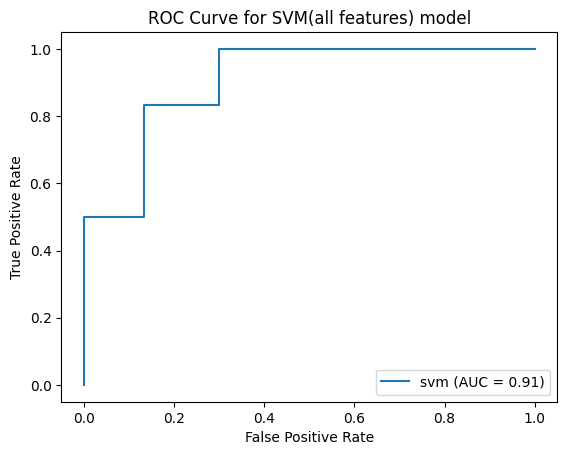

In [90]:
from sklearn.metrics import roc_auc_score, roc_curve

y_proba = svm.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'{'svm'} (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM(all features) model')
plt.legend()
plt.show()

<Axes: >

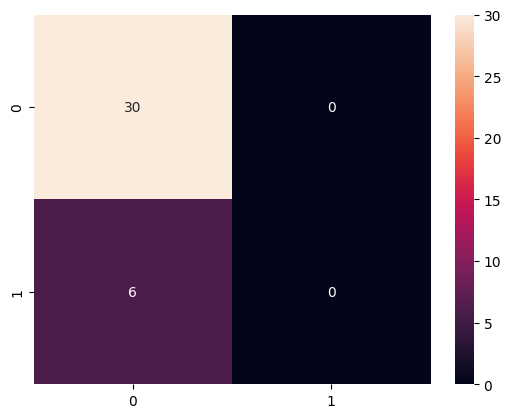

In [91]:
#confusion plot and ROC curve of 'selected features' model

cm_selected=confusion_matrix(y_test,y_pred_svm1)
sns.heatmap(cm_selected,annot=True)

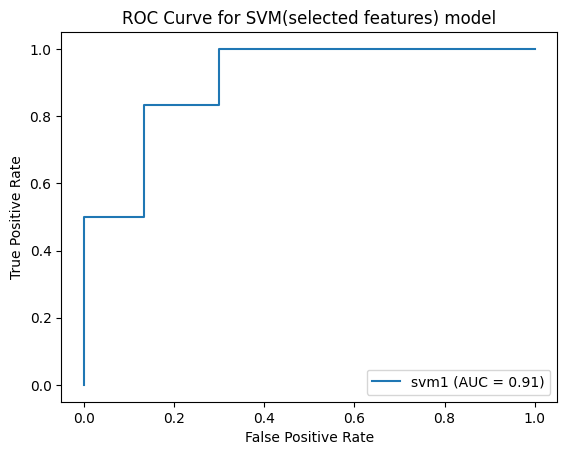

In [92]:
y_proba = svm_selected.predict_proba(x1_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'{'svm1'} (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM(selected features) model')
plt.legend()
plt.show()